# 03 — FinCast Smoke Test

Have the frozen FinCast foundation model forecast our downloaded ETF data and visually inspect whether the forecasts look reasonable. This notebook does **not** train anything — it only runs FinCast in inference mode and plots predictions against realized prices.

Run Jupyter from the project root (`Comp5329_Assignment2_2026/`) so `Path.cwd()` resolves to the workspace. FinCast itself is frozen (`models/FinCast/v1.pth`) and `FinCast-fts/` is treated as read-only upstream code.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

WORKSPACE_ROOT = Path.cwd().resolve()
if WORKSPACE_ROOT.name == 'notebooks':
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from src.datasets.sources import load_close_csv
from src.fincast_io.cache_builder import FORECAST_CHANNEL_NAMES

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'workspace: {WORKSPACE_ROOT}')
print(f'device:    {device}')
print(f'channels:  {FORECAST_CHANNEL_NAMES}')


workspace: E:\Working Area\Comp5329_Assignment2_2026
device:    cuda
channels:  ('mean', 'q10', 'q20', 'q30', 'q40', 'q50', 'q60', 'q70', 'q80', 'q90')


## 1. Config

All hyperparameters live inline — edit a value and re-run. `csv_path` points at whatever `scripts/download_prices.py` produced; `ticker` picks which column to forecast. FinCast loads from frozen weights at `models/FinCast/v1.pth` and the upstream code in `FinCast-fts/`.

In [2]:
seed = 42
torch.manual_seed(seed)

# Data
csv_path = WORKSPACE_ROOT / 'data/raw/etf_daily_close.csv'
ticker = 'SPY'  # CSV has SPY/QQQ/IWM/TLT/GLD/EEM/USO/UUP

# FinCast inference
model_path = WORKSPACE_ROOT / 'models/FinCast/v1.pth'
fincast_root = WORKSPACE_ROOT / 'FinCast-fts'
context_len = 128
horizon_len = 32
data_frequency = 'D'
backend = 'gpu'

print(f'csv:         {csv_path}')
print(f'ticker:      {ticker}')
print(f'model_path:  {model_path}')
print(f'context_len: {context_len}')
print(f'horizon_len: {horizon_len}')
print(f'frequency:   {data_frequency}')
print(f'backend:     {backend}')

csv:         E:\Working Area\Comp5329_Assignment2_2026\data\raw\etf_daily_close.csv
ticker:      SPY
model_path:  E:\Working Area\Comp5329_Assignment2_2026\models\FinCast\v1.pth
context_len: 128
horizon_len: 32
frequency:   D
backend:     gpu


## 2. Load the single-asset close series

`load_close_csv` validates the file and drops any rows containing NaN. We pull a single column for the chosen ticker.

In [3]:
close_df = load_close_csv(csv_path)
if ticker not in close_df.columns:
    raise KeyError(f'Ticker {ticker!r} not in CSV columns: {list(close_df.columns)}')

dates = pd.to_datetime(close_df['Date']).reset_index(drop=True)
values = close_df[ticker].astype(np.float32).to_numpy()

print(f'rows:        {len(values)}')
print(f'date range:  {dates.iloc[0].date()} .. {dates.iloc[-1].date()}')
print(f'price range: {values.min():.2f} .. {values.max():.2f}')
print(f'first 5:     {values[:5]}')
print(f'last  5:     {values[-5:]}')

rows:        4829
date range:  2007-03-01 .. 2026-05-08
price range: 49.81 .. 737.62
first 5:     [98.5212   97.231026 96.30555  97.95325  97.8551  ]
last  5:     [718.01 723.77 733.83 731.58 737.62]


## 3. Pick a context window

Take the most recent `context_len + horizon_len` days. The first `context_len` days are FinCast's input; the trailing `horizon_len` days are the realized ground truth we'll compare the forecast against.

In [4]:
total_needed = context_len + horizon_len
if len(values) < total_needed:
    raise ValueError(f'Need at least {total_needed} days, have {len(values)}.')

context = values[-total_needed:-horizon_len].astype(np.float32)
future_actual = values[-horizon_len:].astype(np.float32)
context_dates = dates.iloc[-total_needed:-horizon_len].reset_index(drop=True)
future_dates = dates.iloc[-horizon_len:].reset_index(drop=True)
last_value = float(context[-1])

print(f'context shape:    {context.shape}')
print(f'context dates:    {context_dates.iloc[0].date()} .. {context_dates.iloc[-1].date()}')
print(f'future dates:     {future_dates.iloc[0].date()} .. {future_dates.iloc[-1].date()}')
print(f'last_value (t0):  {last_value:.4f}')
print(f'future actual:    {future_actual[0]:.4f} .. {future_actual[-1]:.4f}')

context shape:    (128,)
context dates:    2025-09-19 .. 2026-03-24
future dates:     2026-03-25 .. 2026-05-08
last_value (t0):  653.1800
future actual:    656.8200 .. 737.6200


## 4. Load frozen FinCast

Inject `FinCast-fts/src` into `sys.path`, then build a `SimpleNamespace` config matching `tools.inference_utils.get_model_api`. The model loads weights from `models/FinCast/v1.pth`; we never modify it.

In [5]:
fincast_src = fincast_root / 'src'
if str(fincast_src) not in sys.path:
    sys.path.insert(0, str(fincast_src))

from tools.inference_utils import freq_reader_inference, get_model_api

fincast_config = SimpleNamespace(
    model_path=str(model_path),
    backend=backend,
    horizon_len=horizon_len,
    context_len=context_len,
    num_experts=4,
    gating_top_n=2,
    load_from_compile=True,
    forecast_mode='mean',
)
model_api = get_model_api(fincast_config)
freq_value = freq_reader_inference(data_frequency)
print(f'model loaded.  freq_value = {freq_value}')

Loaded PyTorch FinCast, python version 3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)].
model loaded.  freq_value = 0


## 5. Run the forecast

`model_api.forecast` returns `(mean, full)` where `full` has shape `[B, T, 10]` — channels are mean, q10, q20, ..., q90 (see `FORECAST_CHANNEL_NAMES`). We keep only the last `horizon_len` timesteps and unpack the channels.

In [6]:
_, full = model_api.forecast([context], freq=[freq_value])
full = np.asarray(full, dtype=np.float32)
forecast = full[0, -horizon_len:, :]

ch = {name: idx for idx, name in enumerate(FORECAST_CHANNEL_NAMES)}
mean_path = forecast[:, ch['mean']]
q10 = forecast[:, ch['q10']]
q50 = forecast[:, ch['q50']]
q90 = forecast[:, ch['q90']]

abs_err = np.abs(mean_path - future_actual)
print(f'forecast shape:   {forecast.shape}  (horizon x channels)')
print(f'mean[0..2]:       {mean_path[:3]}')
print(f'q10/q50/q90[-1]:  {q10[-1]:.4f} / {q50[-1]:.4f} / {q90[-1]:.4f}')
print(f'actual[-1]:       {future_actual[-1]:.4f}')
print(f'MAE over horizon: {abs_err.mean():.4f}')
print(f'MAPE over horizon:{(abs_err / np.abs(future_actual)).mean() * 100:.2f}%')

forecast shape:   (32, 10)  (horizon x channels)
mean[0..2]:       [651.61115 651.43286 651.0452 ]
q10/q50/q90[-1]:  615.0584 / 646.5383 / 677.1822
actual[-1]:       737.6200
MAE over horizon: 45.8330
MAPE over horizon:6.46%


## 6. Plot context + forecast vs realized

Top panel: price level — the context series, the actual future, the forecast mean/median, and the q10/q90 fan.  
Bottom panel: return space — same forecast/realized divided by the last context price (`forecast / last_value - 1`) so the y-axis is interpretable in percent.

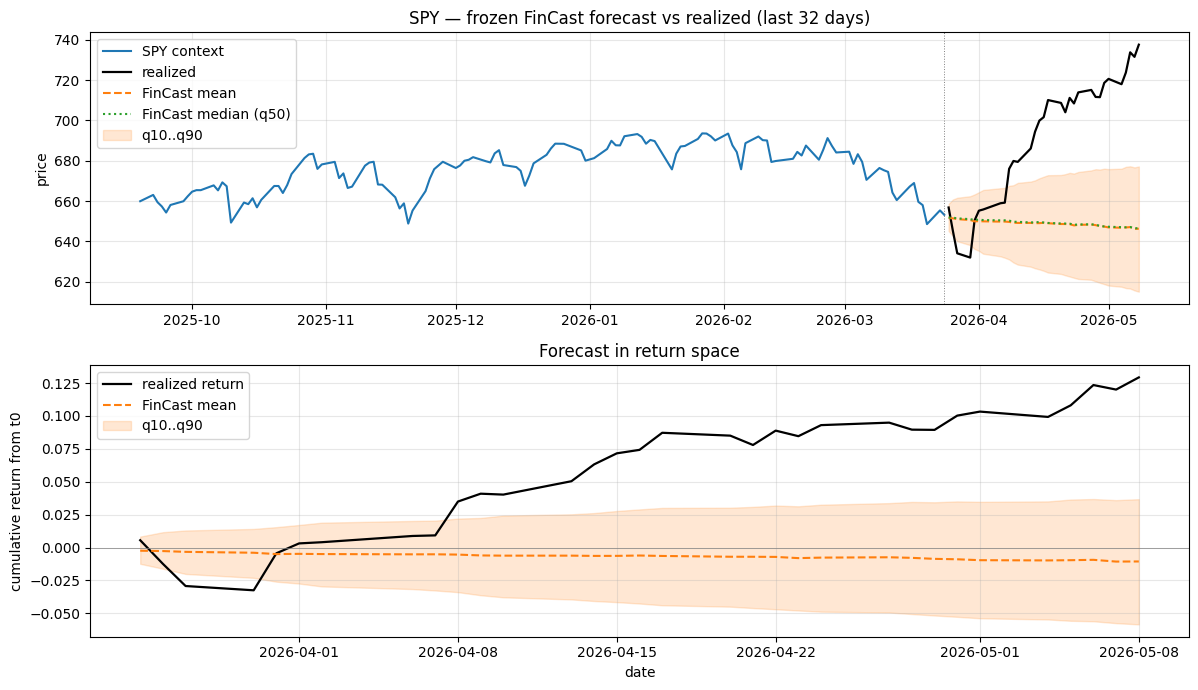

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

ax = axes[0]
ax.plot(context_dates, context, color='C0', label=f'{ticker} context')
ax.plot(future_dates, future_actual, color='k', linewidth=1.6, label='realized')
ax.plot(future_dates, mean_path, color='C1', linestyle='--', label='FinCast mean')
ax.plot(future_dates, q50, color='C2', linestyle=':', label='FinCast median (q50)')
ax.fill_between(future_dates, q10, q90, color='C1', alpha=0.18, label='q10..q90')
ax.axvline(context_dates.iloc[-1], color='gray', linewidth=0.7, linestyle=':')
ax.set_ylabel('price')
ax.set_title(f'{ticker} — frozen FinCast forecast vs realized (last {horizon_len} days)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(future_dates, future_actual / last_value - 1.0, color='k', linewidth=1.6, label='realized return')
ax.plot(future_dates, mean_path / last_value - 1.0, color='C1', linestyle='--', label='FinCast mean')
ax.fill_between(
    future_dates,
    q10 / last_value - 1.0,
    q90 / last_value - 1.0,
    color='C1', alpha=0.18, label='q10..q90',
)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('cumulative return from t0')
ax.set_xlabel('date')
ax.set_title('Forecast in return space')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Sanity-check on multiple windows

Pick four well-separated dates in the series and forecast each one as a batch. This shows whether the predictions look reasonable across different market regimes (early data, mid, recent crisis, latest).

In [ ]:
n_windows = 4
first_end = context_len - 1
last_end = len(values) - horizon_len - 1
end_positions = np.linspace(first_end, last_end, n_windows, dtype=np.int64)

batch_contexts = []
batch_actuals = []
batch_context_dates = []
batch_future_dates = []
batch_last_values = []
for end_idx in end_positions:
    start_idx = end_idx - context_len + 1
    ctx = values[start_idx : end_idx + 1].astype(np.float32)
    fut = values[end_idx + 1 : end_idx + 1 + horizon_len].astype(np.float32)
    batch_contexts.append(ctx)
    batch_actuals.append(fut)
    batch_context_dates.append(dates.iloc[start_idx : end_idx + 1].reset_index(drop=True))
    batch_future_dates.append(dates.iloc[end_idx + 1 : end_idx + 1 + horizon_len].reset_index(drop=True))
    batch_last_values.append(float(ctx[-1]))

_, full_batch = model_api.forecast(batch_contexts, freq=[freq_value] * n_windows)
full_batch = np.asarray(full_batch, dtype=np.float32)[:, -horizon_len:, :]
print(f'batch forecast shape: {full_batch.shape}')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, ax in enumerate(axes.ravel()):
    ctx = batch_contexts[i]
    fut = batch_actuals[i]
    cd = batch_context_dates[i]
    fd = batch_future_dates[i]
    fc = full_batch[i]
    mean_p = fc[:, ch['mean']]
    q10_p = fc[:, ch['q10']]
    q90_p = fc[:, ch['q90']]

    ax.plot(cd, ctx, color='C0', linewidth=1.0, label='context')
    ax.plot(fd, fut, color='k', linewidth=1.4, label='realized')
    ax.plot(fd, mean_p, color='C1', linestyle='--', label='FinCast mean')
    ax.fill_between(fd, q10_p, q90_p, color='C1', alpha=0.18, label='q10..q90')
    ax.axvline(cd.iloc[-1], color='gray', linewidth=0.6, linestyle=':')
    ax.set_title(f'forecast from {cd.iloc[-1].date()}  →  {fd.iloc[-1].date()}')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='best', fontsize=8)

plt.suptitle(f'{ticker} — FinCast across {n_windows} windows', y=1.02)
plt.tight_layout()
plt.show()